# L6 · Variance propagation: $\operatorname{Var}(z)=n\,\operatorname{Var}(w)\,\operatorname{Var}(x)$

**One idea:** for $z=\sum_i w_i x_i$ with independent zero-mean terms, the output
variance is $n\,\operatorname{Var}(w)\,\operatorname{Var}(x)$. Getting this factor
right is what initialization is about.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n = 100          # fan-in
trials = 20000
x = np.random.normal(0, 1, size=(trials, n))   # Var(x)=1

def output_var(std_w):
    W = np.random.normal(0, std_w, size=(trials, n))
    z = np.sum(W * x, axis=1)
    return z.var()

## Reproduce the four cases (fan-in $n=100$, $\operatorname{Var}(x)=1$)
Theory says $\operatorname{Var}(z)=n\,\operatorname{Var}(w)$.

In [2]:
cases = {
    "A  tiny  std=0.01": 0.01,
    "B  large std=1.0 ": 1.0,
    "C  Xavier 1/n    ": np.sqrt(1/n),
    "D  He     2/n    ": np.sqrt(2/n),
}
print(f"{'case':20s} {'Var(w)':>10s} {'theory n*Var(w)':>16s} {'empirical':>12s}")
emp, theo = [], []
for name, std_w in cases.items():
    e = output_var(std_w)
    t = n * std_w**2
    emp.append(e); theo.append(t)
    print(f"{name:20s} {std_w**2:10.5f} {t:16.3f} {e:12.3f}")

case                     Var(w)  theory n*Var(w)    empirical
A  tiny  std=0.01       0.00010            0.010        0.010
B  large std=1.0        1.00000          100.000       99.725
C  Xavier 1/n           0.01000            1.000        1.004
D  He     2/n           0.02000            2.000        1.954


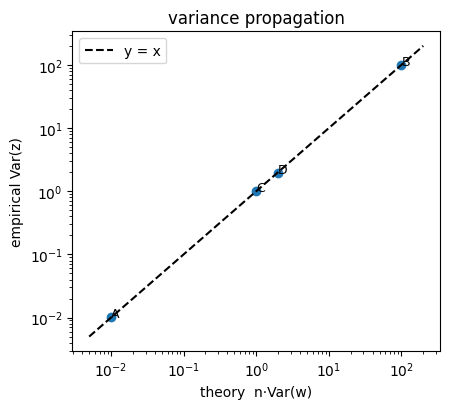

In [3]:
plt.figure(figsize=(4.6, 4.2))
plt.loglog(theo, emp, "o")
lim = [min(theo)*0.5, max(theo)*2]
plt.loglog(lim, lim, "k--", label="y = x")
for (name, _), t, e in zip(cases.items(), theo, emp):
    plt.annotate(name.split()[0], (t, e), fontsize=9)
plt.xlabel("theory  n·Var(w)"); plt.ylabel("empirical Var(z)")
plt.title("variance propagation"); plt.legend(); plt.tight_layout(); plt.show()

## Takeaway
- Empirical $\operatorname{Var}(z)$ matches $n\,\operatorname{Var}(w)\,\operatorname{Var}(x)$.
- To **preserve** signal scale we need $n\,\operatorname{Var}(w)\approx1$, i.e.
  $\operatorname{Var}(w)\approx1/n$ (Xavier). A small per-layer mismatch compounds
  as $c^L$ across depth — the subject of the next notebook.